In [4]:
import pandas as pd, numpy as np , seaborn as sns, matplotlib.pyplot as plt

In [5]:
df= pd.read_csv("AIML Dataset.csv")

In [6]:
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [7]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [9]:
condition = (df['isFraud'] == 0.0) & (df['isFlaggedFraud'] == 1.0)
print(df.loc[condition, 'type'].value_counts())

Series([], Name: count, dtype: int64)


so there is **no such case** in which

*flagedfraud* = `true` but *isfraud*=`false`



To understand the relationship between `isFraud` and `isFlaggedFraud`, we can create a cross-tabulation and visualize it with a heatmap. This will show us the number of transactions for each combination of these two features.

Cross-tabulation of isFraud vs. isFlaggedFraud:


isFraud,0,1
isFlaggedFraud,,
0,6354407,8197
1,0,16


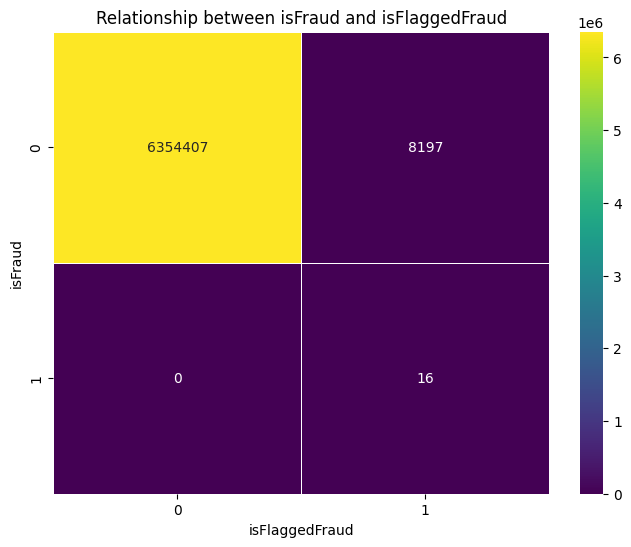

In [10]:
fraud_flag_crosstab = pd.crosstab( df['isFlaggedFraud'],df['isFraud'])

print("Cross-tabulation of isFraud vs. isFlaggedFraud:")
display(fraud_flag_crosstab)

plt.figure(figsize=(8, 6))
sns.heatmap(fraud_flag_crosstab, annot=True, fmt='d', cmap='viridis', linewidths=.5)
plt.title('Relationship between isFraud and isFlaggedFraud')
plt.xlabel('isFlaggedFraud')
plt.ylabel('isFraud')
plt.show()

<Axes: xlabel='isFraud', ylabel='amount'>

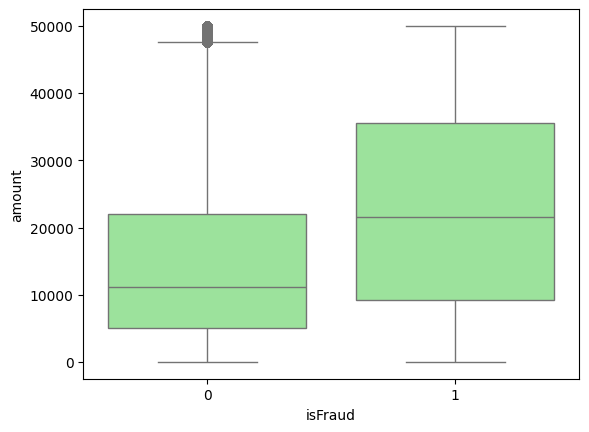

In [11]:
sns.boxplot(data= df[df['amount'] < 50000],x='isFraud',y='amount', color='lightgreen')

In [12]:
df['amount'].max()

92445516.64

In [13]:
a = round((df['isFraud'].value_counts()[1]/ df.shape[0])*100,2)
print(f"the fraud true % = {a}")

the fraud true % = 0.13


In [14]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [15]:
df.drop(columns='step',inplace=True)

In [16]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [17]:
df['balancediffDest']= df['newbalanceDest']- df['oldbalanceDest']
df[df['balancediffDest']<0]['isFraud'].value_counts()

,count
isFraud,
0,1238837
1,27


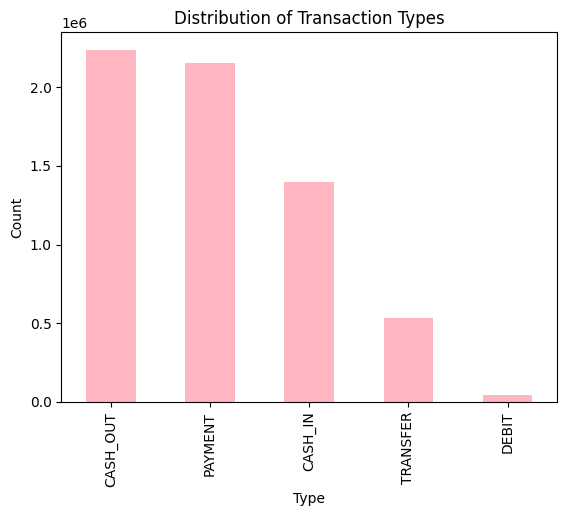

In [18]:

df['type'].value_counts().plot(kind='bar', color= "lightpink")
plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Distribution of Transaction Types')
plt.show()

In [19]:
df.groupby(['type'])['isFraud'].value_counts()

type      isFraud
CASH_IN   0          1399284
CASH_OUT  0          2233384
          1             4116
DEBIT     0            41432
PAYMENT   0          2151495
TRANSFER  0           528812
          1             4097
Name: count, dtype: int64

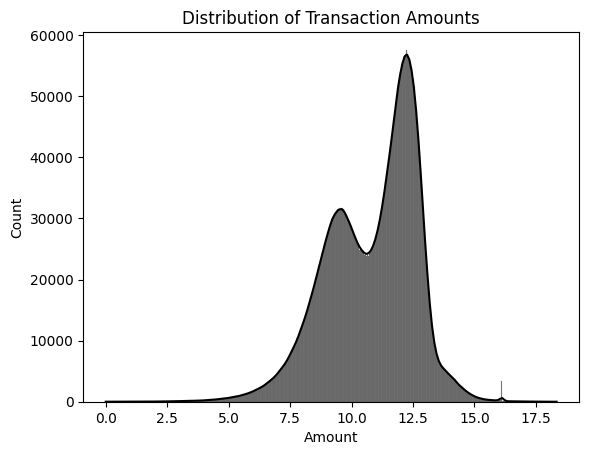

In [21]:
sns.histplot(np.log1p(df['amount']),kde=True, color = "black")
plt.xlabel('Amount')
plt.ylabel('Count')
plt.title('Distribution of Transaction Amounts')
plt.show()

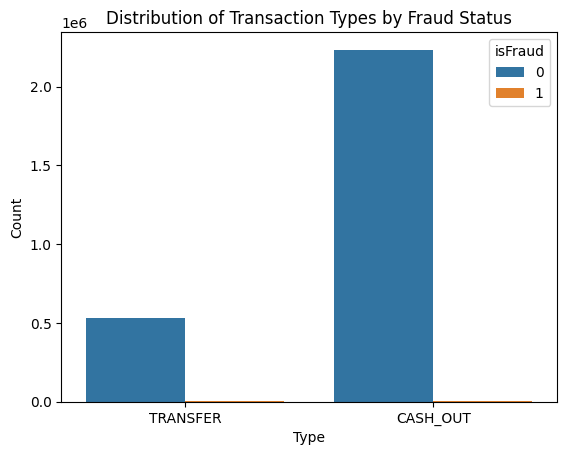

In [40]:
fraud_types = df[df['type'].isin(['TRANSFER','CASH_OUT'])]
# fraud_types['type'].sum()
sns.countplot(data=fraud_types, x='type', hue='isFraud')
plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Distribution of Transaction Types by Fraud Status')
plt.show()

In [22]:
df_model = df.drop(['isFlaggedFraud','nameOrig','nameDest'],axis=1)

In [43]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balancediffDest'],
      dtype='object')

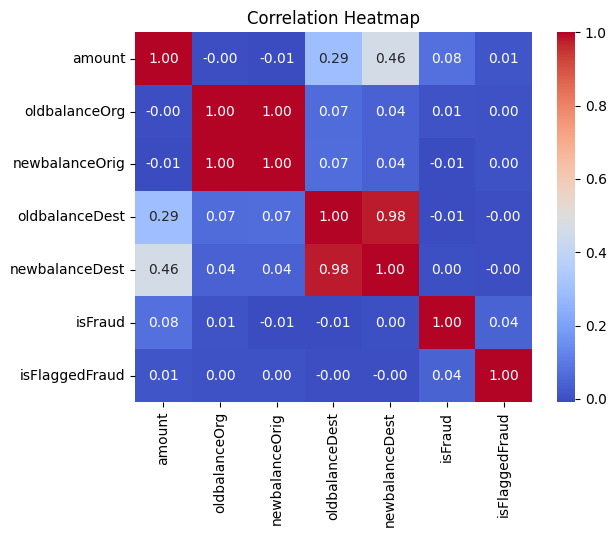

In [52]:
corr = df[[ 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud','isFlaggedFraud']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**MODEL TRAINING....**

In [24]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [23]:
categ = ['type']
num = ['amount',  'oldbalanceOrg', 'newbalanceOrig','oldbalanceDest', 'newbalanceDest']

In [25]:
df['type'].value_counts()

,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


In [27]:
Y = df_model['isFraud']
X= df_model.drop(['isFraud'],axis=1)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3,random_state=42)

In [29]:
preprocessor = ColumnTransformer(
    transformers= [
        ('numerical',StandardScaler(), num),
        ('catagorical',OneHotEncoder(),categ)
    ]
)

In [30]:
Pipe= Pipeline([
    ("pip",preprocessor),
    ("clf",LogisticRegression(class_weight='balanced', max_iter=100))
])

In [31]:
Pipe.fit(X_train,y_train)

Pipeline(steps=[('pip',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('catagorical',
                                                  OneHotEncoder(),
                                                  ['type'])])),
                ('clf', LogisticRegression(class_weight='balanced'))])

In [32]:
pred = Pipe.predict(X_test)

In [33]:
pred[:9]

array([0, 0, 0, 0, 0, 0, 0, 0, 0])

In [34]:
Pipe.score(X_test, y_test)

0.9454045660435481

In [35]:
confusion_matrix(y_test,pred)

array([[1802309,  104042],
       [    169,    2266]])

In [36]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906351
           1       0.02      0.93      0.04      2435

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [37]:
import joblib
joblib.dump(Pipe, "fraud_detection.pkl")

['fraud_detection.pkl']